# <center> 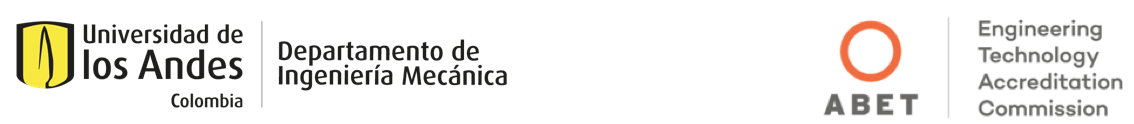
## <span style="color: #147CA6"><center> IMEC 2001-Herramientas Computacionales
## <span style="color: #1AA3D9"><center> Taller 9-ODE

### <span style="color: #147CA6">Fecha Límite de Entrega (Bloque Neón): <font color="#1AA3D9">TODO</font>
___
### <span style="color: #147CA6"> Descripción de la actividad

La actividad tiene como objetivo demostrar su manejo en la descripción de ecuaciones diferenciales ordinarias en Python y su solución numérica.

### <span style="color: #147CA6"> Tener en Cuenta

1. Enviar vía Bloque Neón el archivo en Jupyter Notebook (extensión <font color="#1AA3D9">'.ipynb'</font>).

**Nota:** <font color="#1AA3D9">El nombre del archivo debe ser: `Taller9_NombreApellido1_NombreApellido2.ipynb`.</font>

---

### <span style="color: #1AA3D9"><center> Item 1: Flujo en tuberías

# <center> 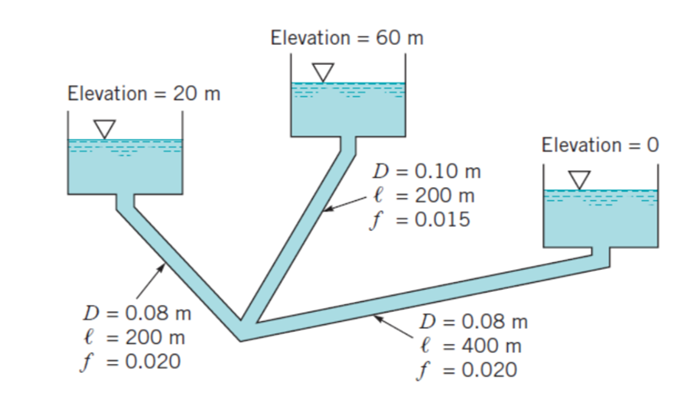 

Utilice el mismo sistema del taller 8, pero esta vez analice el caso en el que cada tanque no es un reservorio infinito. Es decir, en la medida que fluye el agua por un ducto el tanque podría subir (o bajar) de nivel.  Los tanques tienen una geometría cilíndrica con radio de 2 m. Recuerde que para realizar el ODE de la evolución de los niveles de los tanques usted requiere encontrar en cada una de las iteraciones:

<font size="6">$$[\dot{h}_{a},\dot{h}_{b},\dot{h}_{c}]$$ </font>

Siendo cada una, el cambio de las alturas de cada tanque involucrado en el problema. Piense en como el caudal en cada instante ($Q_a,Q_b,Q_c$) se relaciona con $\dot{h}_{a},\dot{h}_{b},\dot{h}_{c}$. Puede verificar si su análisis tiene sentido físicamente si al realizar sus cálculos, las unidades de los cambios de las alturas coinciden con el siguiente análisis dimensional:

$$[\dot{h}]=\frac{[distancia]}{[tiempo]}$$

Puede calcular el caudal como en el taller anterior, pero recuerde que este caudal <span style="color: #1AA3D9"> ahora variará en cada iteración de la solución del ejercicio, es decir, tiene que resolverse múltiples veces<font color="#1AA3D9">.

<span style="color: #1AA3D9">Grafique la evolución del nivel de agua en cada tanque respecto a su elevación inicial en una misma gráfica.

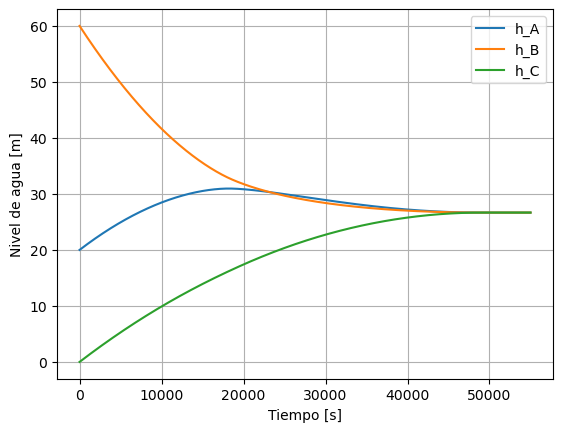

In [17]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

g = 9.81
fa, fb, fc = 0.02, 0.015, 0.02
Da, Db, Dc = 0.08, 0.10, 0.08
la, lb, lc = 200, 200, 400
A_tanque = np.pi * (2**2)

t = np.linspace(0, 55000, 1100)
delta_t = 55000/1100

z = [20.0, 60.0, 0.0]

def eq_optimizar(S, z):
    va, vb, vc, h = S
    return [
        h + (va**2)/(2*g) + (fa*la*(va*abs(va)))/(2*Da*g) - z[0],
        h + (vb**2)/(2*g) + (fb*lb*(vb*abs(vb)))/(2*Db*g) - z[1],
        h + (vc**2)/(2*g) + (fc*lc*(vc*abs(vc)))/(2*Dc*g) - z[2],
        (np.pi*Da**2/4)*va + (np.pi*Db**2/4)*vb + (np.pi*Dc**2/4)*vc
    ]

resultados_ha, resultados_hb, resultados_hc = [], [], []

for _ in t:
    guess = [1, 1, 1, 1]
    sol = fsolve(eq_optimizar, guess, args=(z,))
    va, vb, vc, h = sol

    resultados_ha.append(z[0])
    resultados_hb.append(z[1])
    resultados_hc.append(z[2])

    Qa = (np.pi*Da**2/4)*va
    Qb = (np.pi*Db**2/4)*vb
    Qc = (np.pi*Dc**2/4)*vc

    z[0] -= (Qa * delta_t) / A_tanque
    z[1] -= (Qb * delta_t) / A_tanque
    z[2] -= (Qc * delta_t) / A_tanque

plt.plot(t, resultados_ha, label="h_A")
plt.plot(t, resultados_hb, label="h_B")
plt.plot(t, resultados_hc, label="h_C")
plt.xlabel("Tiempo [s]")
plt.ylabel("Nivel de agua [m]")
plt.legend()
plt.grid(True)
plt.show()


___
### <span style="color: #1AA3D9"><center> Item 2: Modelos dinámicos con masas y resortes

# <center>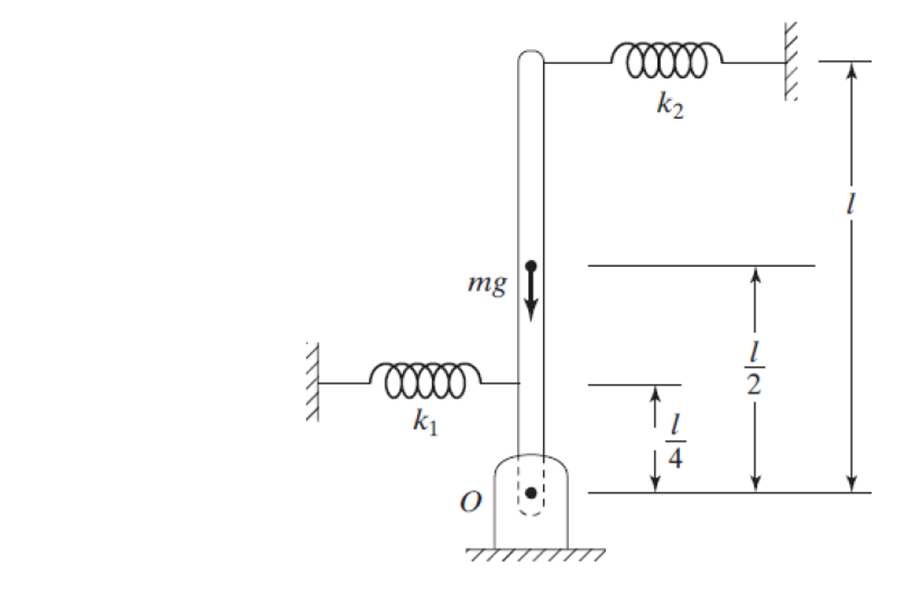

Utilice el mismo sistema del taller 8, pero incluya un torque disipativo producido por fricción viscosa $\tau=-c\dot{\theta}$. Encuentre la respuesta del ángulo de la barra en el tiempo una vez es liberada desde el reposo con una inclinación de 20° CW respecto a la posición mostrada en la figura.

Suponga los siguientes valores.

$$k_1=10 \frac{N}{m}$$
$$k_2=20 \frac{N}{m}$$
$$c=0.1 \frac{Nms}{rad}$$
$$m=1kg$$
$$l=1m$$


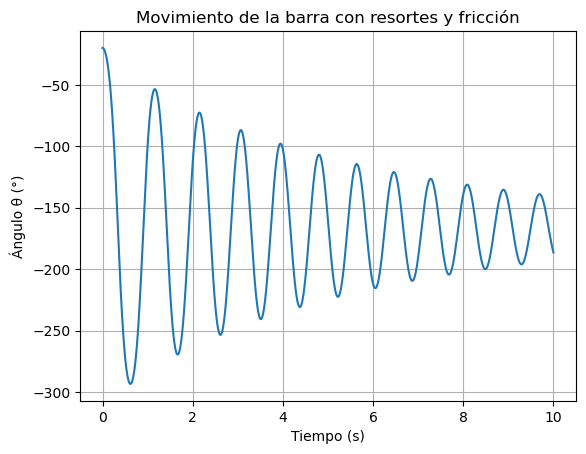

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

k1 = 10.0
k2 = 20.0
c  = 0.1
m  = 1.0
L  = 1.0
g  = 9.81

I = (1/3) * m * L**2

def ecuaciones(t, y):
    theta = y[0]
    theta_p = y[1]

    M_resorte1 = k1 * (L**2/16) * np.sin(theta)
    M_resorte2 = k2 * (L**2) * np.sin(theta)
    M_peso     = m * g * (L/2) * np.cos(theta)
    M_fric     = -c * theta_p
    theta_pp = (M_resorte1 + M_resorte2 - M_peso + M_fric) / I
    
    return [theta_p, theta_pp]

theta_inicial = np.deg2rad(-20)  # arranca 20° a la derecha
y0 = [theta_inicial, 0.0]

t_final = 10
t_eval = np.linspace(0, t_final, 1000)
sol = solve_ivp(ecuaciones, [0, t_final], y0, t_eval=t_eval)

theta_grados = np.rad2deg(sol.y[0])

plt.plot(sol.t, theta_grados)
plt.xlabel("Tiempo (s)")
plt.ylabel("Ángulo θ (°)")
plt.title("Movimiento de la barra con resortes y fricción")
plt.grid()
plt.show()